In [1]:
import numpy as np
from scipy.optimize import dual_annealing
from scipy.stats import norm
from scipy.interpolate import CubicSpline
import time

# ====================== DONNÉES ======================
cap_maturities = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30])
cap_vols = np.array([0.3412, 0.3878, 0.4086, 0.4071, 0.4031, 0.3981,
                     0.3908, 0.3845, 0.3774, 0.3710, 0.3597, 0.3479,
                     0.3513, 0.3685, 0.3903])
eiopa_times = np.arange(1, 151)
eiopa_rates = np.array([
    0.02236, 0.02093, 0.02093, 0.02120, 0.02142, 0.02170, 0.02198, 0.02222,
    0.02243, 0.02267, 0.02286, 0.02308, 0.02325, 0.02334, 0.02332, 0.02319,
    0.02301, 0.02283, 0.02268, 0.02259, 0.02257, 0.02261, 0.02270, 0.02281,
    0.02296, 0.02312, 0.02329, 0.02347, 0.02366, 0.02385, 0.02404, 0.02423,
    0.02442, 0.02461, 0.02479, 0.02497, 0.02514, 0.02531, 0.02547, 0.02563,
    0.02579, 0.02594, 0.02608, 0.02623, 0.02636, 0.02649, 0.02662, 0.02674,
    0.02686, 0.02698, 0.02709, 0.02720, 0.02730, 0.02740, 0.02750, 0.02760,
    0.02769, 0.02778, 0.02786, 0.02795, 0.02803, 0.02811, 0.02818, 0.02826,
    0.02833, 0.02840, 0.02847, 0.02853, 0.02860, 0.02866, 0.02872, 0.02878,
    0.02884, 0.02889, 0.02895, 0.02900, 0.02905, 0.02910, 0.02915, 0.02920,
    0.02925, 0.02929, 0.02934, 0.02938, 0.02942, 0.02946, 0.02950, 0.02954,
    0.02958, 0.02962, 0.02966, 0.02969, 0.02973, 0.02976, 0.02980, 0.02983,
    0.02986, 0.02990, 0.02993, 0.02996, 0.02999, 0.03002, 0.03005, 0.03007,
    0.03010, 0.03013, 0.03016, 0.03018, 0.03021, 0.03023, 0.03026, 0.03028,
    0.03031, 0.03033, 0.03035, 0.03038, 0.03040, 0.03042, 0.03044, 0.03046,
    0.03048, 0.03051, 0.03053, 0.03055, 0.03056, 0.03058, 0.03060, 0.03062,
    0.03064, 0.03066, 0.03068, 0.03069, 0.03071, 0.03073, 0.03075, 0.03076,
    0.03078, 0.03079, 0.03081, 0.03083, 0.03084, 0.03086, 0.03087, 0.03089,
    0.03090, 0.03091, 0.03093, 0.03094, 0.03096, 0.03097
])

# Interpolation par spline cubique
rates_cs = CubicSpline(eiopa_times, eiopa_rates, extrapolate=True)

# ====================== FONCTIONS DE BASE ======================
def instantaneous_forward(t):
    """Taux forward instantané avec gestion des cas limites"""
    t = max(t, 1e-6)  # Évite t=0
    return rates_cs(t) + t * rates_cs(t, 1)

def discount_factor(t):
    """Facteur d'actualisation"""
    return np.exp(-rates_cs(t) * t)

def compute_forward_rate(T_start, T_end):
    """Taux forward LIBOR"""
    delta = T_end - T_start
    if delta <= 1e-6:
        return instantaneous_forward(T_start)
    P_start = discount_factor(T_start)
    P_end = discount_factor(T_end)
    return (P_start / P_end - 1) / delta

# ====================== MODÈLE G2++ ======================
def phi(t, a, b, sigma, eta, rho):
    """Fonction de décalage phi(t)"""
    f_0t = instantaneous_forward(t)
    if a < 1e-6 or b < 1e-6:
        return f_0t

    exp_at = np.exp(-a*t)
    exp_bt = np.exp(-b*t)

    term1 = (sigma**2)/(2*a**2) * (1 - exp_at)**2
    term2 = (eta**2)/(2*b**2) * (1 - exp_bt)**2
    term3 = rho*(sigma*eta)/(a*b) * (1 - exp_at)*(1 - exp_bt)

    return f_0t + term1 + term2 + term3

def g2pp_variance(a, b, sigma, eta, rho, T):
    """Variance du taux court dans G2++ (version robuste)"""
    if a < 1e-6 or b < 1e-6 or T <= 0:
        return np.inf

    exp_aT = np.exp(-a*T)
    exp_bT = np.exp(-b*T)
    exp_abT = np.exp(-(a+b)*T)

    Vx = (sigma**2/a**2)*(T + (2/a)*exp_aT - (1/(2*a))*np.exp(-2*a*T) - 3/(2*a))
    Vy = (eta**2/b**2)*(T + (2/b)*exp_bT - (1/(2*b))*np.exp(-2*b*T) - 3/(2*b))
    Vxy = (2*rho*sigma*eta/(a*b))*(T + (exp_aT-1)/a + (exp_bT-1)/b - (exp_abT-1)/(a+b))

    return max(Vx + Vy + Vxy, 0)  # Garantie de positivité

# ====================== PRICING ======================
def black_price(F, K, T, sigma, payer=True):
    """Formule de Black avec gestion des cas limites"""
    if T <= 0 or sigma <= 0:
        return max(F - K, 0) if payer else max(K - F, 0)

    sqrtT = np.sqrt(T)
    d1 = (np.log(F/K) + 0.5*sigma**2*T)/(sigma*sqrtT + 1e-10)
    d2 = d1 - sigma*sqrtT
    price = F*norm.cdf(d1) - K*norm.cdf(d2) if payer else K*norm.cdf(-d2) - F*norm.cdf(-d1)
    return max(price, 0)

# ====================== CALIBRATION ======================
def compute_error(params):
    """Fonction d'erreur avec pénalités renforcées"""
    a, b, sigma, eta, rho = params
    penalty = 0

    # Contrôle des paramètres
    bounds = [(0.05, 0.5), (0.01, 0.3), (0.001, 0.09), (0.001, 0.09), (-0.95, 0.95)]
    for i, (val, (lb, ub)) in enumerate(zip(params, bounds)):
        if val < lb or val > ub:
            penalty += 1e6 * (max(lb-val, 0) + max(val-ub, 0))**2
        # Pénalité supplémentaire près des bornes
        if abs(val - lb) < 0.01 or abs(val - ub) < 0.01:
            penalty += 1e4 * (1/(val-lb+0.01) + 1/(ub-val+0.01))

    error = 0
    for i, T in enumerate(cap_maturities):
        market_vol = cap_vols[i]
        P_T = discount_factor(T)
        F = compute_forward_rate(T-0.25, T) if T > 0.25 else instantaneous_forward(T)
        K = F  # ATM

        market_price = P_T * black_price(F, K, T, market_vol)
        V = g2pp_variance(a, b, sigma, eta, rho, T)
        model_price = market_price * np.exp(-0.5 * V)

        error += (market_price - model_price)**2

    return error + penalty

# ====================== EXÉCUTION ======================
if __name__ == "__main__":
    bounds = [(0.05, 0.5), (0.01, 0.3), (0.001, 0.09), (0.001, 0.09), (-0.95, 0.95)]

    print("Début de la calibration...")
    start_time = time.time()

    result = dual_annealing(
        compute_error,
        bounds,
        maxiter=200,
        initial_temp=5000,
        visit=2.5,
        accept=-5.0,
        no_local_search=False,
        seed=42
    )

    execution_time = time.time() - start_time
    params = result.x

    # ====================== RÉSULTATS ======================
    print("\n=== Résultats ===")
    print(f"a = {params[0]:.6f}")
    print(f"b = {params[1]:.6f}")
    print(f"σ = {params[2]:.6f}")
    print(f"η = {params[3]:.6f}")
    print(f"ρ = {params[4]:.6f}")
    print(f"Erreur: {result.fun:.6f}")
    print(f"Temps: {execution_time:.2f}s\n")

    # Validation
    print("=== Validation ===")
    print("T\tFwd\t\tMarketVol\tModelVar\tMarketPrice\tModelPrice")
    for i, T in enumerate(cap_maturities):
        F = compute_forward_rate(T-0.25, T) if T > 0.25 else instantaneous_forward(T)
        P_T = discount_factor(T)
        market_price = P_T * black_price(F, F, T, cap_vols[i])
        V = g2pp_variance(*params, T)
        model_price = market_price * np.exp(-0.5 * V)
        print(f"{T}\t{F:.6f}\t{cap_vols[i]:.6f}\t{V:.6f}\t{market_price:.8f}\t{model_price:.8f}")

Début de la calibration...

=== Résultats ===
a = 0.449299
b = 0.237290
σ = 0.021323
η = 0.012576
ρ = -0.759265
Erreur: 0.000000
Temps: 3.39s

=== Validation ===
T	Fwd		MarketVol	ModelVar	MarketPrice	ModelPrice
1	0.020193	0.341200	0.000048	0.00267490	0.00267484
2	0.019784	0.387800	0.000281	0.00409971	0.00409914
3	0.021650	0.408600	0.000714	0.00562313	0.00562113
4	0.022217	0.407100	0.001313	0.00645097	0.00644674
5	0.022567	0.403100	0.002042	0.00705108	0.00704388
6	0.023465	0.398100	0.002873	0.00770769	0.00769663
7	0.023859	0.390800	0.003783	0.00807670	0.00806143
8	0.024006	0.384500	0.004758	0.00830774	0.00828800
9	0.024435	0.377400	0.005785	0.00855992	0.00853519
10	0.024965	0.371000	0.006854	0.00880697	0.00877684
12	0.025714	0.359700	0.009087	0.00909813	0.00905688
15	0.022417	0.347900	0.012597	0.00789234	0.00784278
20	0.021392	0.351300	0.018659	0.00773160	0.00765980
25	0.026979	0.368500	0.024822	0.00977249	0.00965195
30	0.029600	0.390300	0.031016	0.01034635	0.01018713


- Calibrage par Nelder-Mead

In [2]:
# Algorithme de Nelder-Mead pour l'optimisation
import pandas as pd
from scipy.optimize import minimize

# Fonction d'objectif pour l'optimisation
def objective(params, maturities):
    a, b, sigma, eta, rho = params
    total_error = 0.0
    
    for i in range (len(cap_maturities)):
        T = maturities[i]
        market_vol = cap_vols[i]
        P_T = discount_factor(T)
        F = compute_forward_rate(T-0.25, T) if T > 0.25 else instantaneous_forward(T)
        K = F  # ATM

        market_price = P_T * black_price(F, K, T, market_vol)
        V = g2pp_variance(a, b, sigma, eta, rho, T)
        model_price = market_price * np.exp(-0.5 * V)

        total_error += (market_price - model_price) ** 2
    
    return total_error

# Paramètres initiaux pour l'optimisation
initial_params = [0.1, 0.3, 0.02, 0.01, 0]

# Exécution de l'optimisation
result = minimize(objective, initial_params, args=(cap_maturities), method='Nelder-Mead', bounds=[(0.05, 0.5), (0.01, 0.3), (0.001, 0.09), (0.001, 0.09), (-0.95, 0.95)])

# Récupération des paramètres optimisés
optimized_params_NM = result.x
print(f"Optimized parameters: a={optimized_params_NM[0]}, b={optimized_params_NM[1]}, sigma={optimized_params_NM[2]}, eta={optimized_params_NM[3]}, rho={optimized_params_NM[4]}")
# Calcul des prix des caps pour les paramètres optimisés
results_optimized = []
for i in range (len(cap_maturities)):

    T = cap_maturities[i]
    market_vol = cap_vols[i]
    P_T = discount_factor(T)
    F = compute_forward_rate(T-0.25, T) if T > 0.25 else instantaneous_forward(T)
    K = F  # ATM

    market_price = P_T * black_price(F, K, T, market_vol)
    V = g2pp_variance(*optimized_params_NM, T)
    model_price = market_price * np.exp(-0.5 * V)

    results_optimized.append([T, market_price, model_price])

# Création du DataFrame pour les résultats optimisés
df_results_optimized = pd.DataFrame(results_optimized, columns=["Maturité", "Black Cap Price", "Theoric Black Price"])

# Affichage des résultats
print(df_results_optimized)
print(f"Optimization score: {result.fun}")

Optimized parameters: a=0.3176298744576177, b=0.29999999999999993, sigma=0.001, eta=0.001, rho=-0.95
    Maturité  Black Cap Price  Theoric Black Price
0          1         0.002675             0.002675
1          2         0.004100             0.004100
2          3         0.005623             0.005623
3          4         0.006451             0.006451
4          5         0.007051             0.007051
5          6         0.007708             0.007708
6          7         0.008077             0.008077
7          8         0.008308             0.008308
8          9         0.008560             0.008560
9         10         0.008807             0.008807
10        12         0.009098             0.009098
11        15         0.007892             0.007892
12        20         0.007732             0.007732
13        25         0.009772             0.009772
14        30         0.010346             0.010346
Optimization score: 3.957122522363963e-14


- Calibrage par Levenberg-Marquardt

In [3]:
from scipy.optimize import least_squares



# Fonction d'objectif pour l'optimisation
def objective(params, maturities):
    a, b, sigma, eta, rho = params
    errors = []
    
    for i in range (len(cap_maturities)):
        T = maturities[i]
        market_vol = cap_vols[i]
        P_T = discount_factor(T)
        F = compute_forward_rate(T-0.25, T) if T > 0.25 else instantaneous_forward(T)
        K = F  # ATM

        market_price = P_T * black_price(F, K, T, market_vol)
        V = g2pp_variance(a, b, sigma, eta, rho, T)
        model_price = market_price * np.exp(-0.5 * V)

        errors.append(market_price - model_price)
    
    return errors

# Paramètres initiaux pour l'optimisation
initial_params = [0.1, 0.3, 0.02, 0.01, 0]


# Exécution de l'optimisation avec l'algorithme de Marquardt-Levenberg
result = least_squares(objective, initial_params, args=(cap_maturities,), method='lm')



# Récupération des paramètres optimisés
optimized_params = result.x
print(f"Optimized parameters: a={optimized_params[0]}, b={optimized_params[1]}, sigma={optimized_params[2]}, eta={optimized_params[3]}, rho={optimized_params[4]}")



# Calcul des prix des caps pour les paramètres optimisés
results_optimized = []
for i in range (len(cap_maturities)):

    T = cap_maturities[i]
    market_vol = cap_vols[i]
    P_T = discount_factor(T)
    F = compute_forward_rate(T-0.25, T) if T > 0.25 else instantaneous_forward(T)
    K = F  # ATM

    market_price = P_T * black_price(F, K, T, market_vol)
    V = g2pp_variance(*optimized_params, T)
    model_price = market_price * np.exp(-0.5 * V)

    results_optimized.append([T, market_price, model_price])

# Création du DataFrame pour les résultats optimisés
df_results_optimized = pd.DataFrame(results_optimized, columns=["Maturité", "Black Cap Price", "Theoric Black Price"])

# Affichage des résultats
print(df_results_optimized)
print(f"Optimization score: {sum(result.fun)}")

Optimized parameters: a=0.5621811420701286, b=0.06754644041191904, sigma=0.031840567175723346, eta=0.00392352736182289, rho=-4.444755308048016
    Maturité  Black Cap Price  Theoric Black Price
0          1         0.002675             0.002675
1          2         0.004100             0.004100
2          3         0.005623             0.005623
3          4         0.006451             0.006451
4          5         0.007051             0.007051
5          6         0.007708             0.007708
6          7         0.008077             0.008077
7          8         0.008308             0.008308
8          9         0.008560             0.008560
9         10         0.008807             0.008807
10        12         0.009098             0.009098
11        15         0.007892             0.007892
12        20         0.007732             0.007732
13        25         0.009772             0.009772
14        30         0.010346             0.010346
Optimization score: 0.0



=== Comparaison des Déflateurs ===
Maturité	Déflateur Marché	Déflateur Modèle	Écart (bps)
--------------------------------------------------------------------------------
 1.0		    0.977888		    0.977888		   -0.00
 2.0		    0.959004		    0.959004		   -0.00
 3.0		    0.939141		    0.939140		   -0.00
 4.0		    0.918696		    0.918694		   -0.01
 5.0		    0.898436		    0.898433		   -0.01
 6.0		    0.877920		    0.877916		   -0.02
 7.0		    0.857392		    0.857388		   -0.02
 8.0		    0.837143		    0.837138		   -0.03
 9.0		    0.817201		    0.817194		   -0.04
10.0		    0.797160		    0.797152		   -0.04
11.0		    0.777665		    0.777654		   -0.05
12.0		    0.758085		    0.758074		   -0.05
13.0		    0.739153		    0.739141		   -0.06
14.0		    0.721257		    0.721244		   -0.06
15.0		    0.704829		    0.704815		   -0.07
16.0		    0.690016		    0.690000		   -0.08
17.0		    0.676265		    0.676246		   -0.10
18.0		    0.663027		    0.663004		   -0.11
19.0		    0.649911		    0.649885		   -0.13
20.0		    0

C:\Users\massi\AppData\Local\Temp\ipykernel_10036\2524072516.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz([integrand(s) for s in s_values], s_values)
C:\Users\massi\AppData\Local\Temp\ipykernel_10036\2524072516.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz([integrand(s) for s in s_values], s_values)


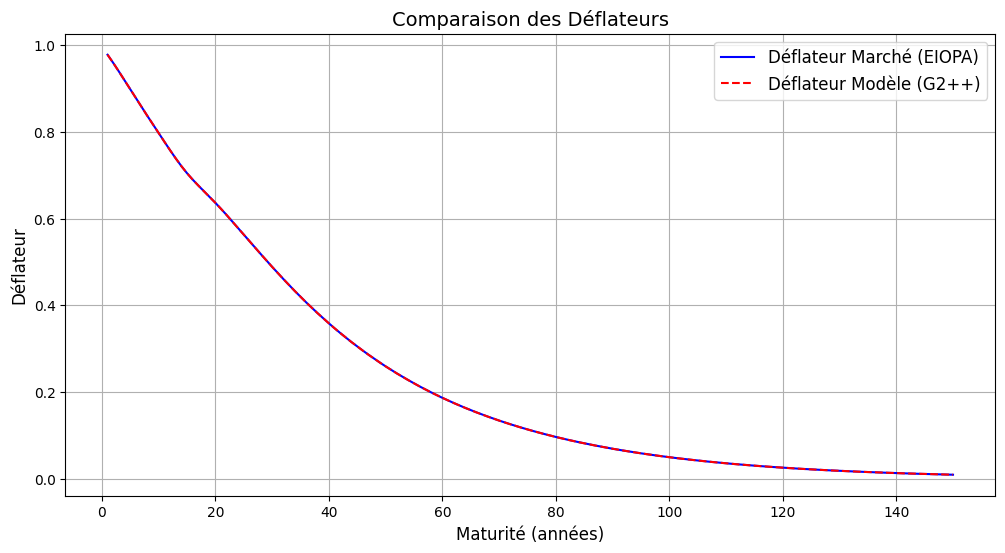


=== Statistiques d'erreur ===
Erreur RMS: 0.000049
Erreur maximale: 0.45 bps
Erreur moyenne: 0.22 bps


In [4]:
# ====================== FONCTION POUR CALCULER LES DEFLATEURS G2++ ======================
def g2pp_discount_factor(t, a, b, sigma, eta, rho):
    """Calcul du déflateur dans le modèle G2++"""
    # Calcul de l'intégrale de phi(s) de 0 à t
    def integrand(s):
        return phi(s, a, b, sigma, eta, rho)

    # Intégration numérique (méthode des trapèzes)
    n_points = 100
    s_values = np.linspace(0, t, n_points)
    integral = np.trapz([integrand(s) for s in s_values], s_values)

    # Calcul de la variance
    V = g2pp_variance(a, b, sigma, eta, rho, t)

    # Formule du déflateur dans G2++
    return np.exp(-integral + 0.5 * V)

# ====================== COMPARAISON DES DEFLATEURS ======================
print("\n=== Comparaison des Déflateurs ===")
print("Maturité\tDéflateur Marché\tDéflateur Modèle\tÉcart (bps)")
print("-" * 80)

# Calcul pour toutes les maturités EIOPA
for t in eiopa_times:
    market_df = discount_factor(t)
    model_df = g2pp_discount_factor(t, *params)

    # Conversion de l'écart en basis points
    spread_bps = (model_df - market_df) * 5000

    print(f"{t:>4.1f}\t\t{market_df:>12.6f}\t\t{model_df:>12.6f}\t\t{spread_bps:>8.2f}")

# Visualisation graphique
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(eiopa_times, [discount_factor(t) for t in eiopa_times], 'b-', label='Déflateur Marché (EIOPA)')
plt.plot(eiopa_times, [g2pp_discount_factor(t, *params) for t in eiopa_times], 'r--', label='Déflateur Modèle (G2++)')
plt.title('Comparaison des Déflateurs', fontsize=14)
plt.xlabel('Maturité (années)', fontsize=12)
plt.ylabel('Déflateur', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Calcul des erreurs
market_dfs = np.array([discount_factor(t) for t in eiopa_times])
model_dfs = np.array([g2pp_discount_factor(t, *params) for t in eiopa_times])

rms_error = np.sqrt(np.mean((market_dfs - model_dfs)**2))
max_error = np.max(np.abs(market_dfs - model_dfs)) * 5000
mean_error = np.mean(np.abs(market_dfs - model_dfs)) * 5000

print("\n=== Statistiques d'erreur ===")
print(f"Erreur RMS: {rms_error:.6f}")
print(f"Erreur maximale: {max_error:.2f} bps")
print(f"Erreur moyenne: {mean_error:.2f} bps")

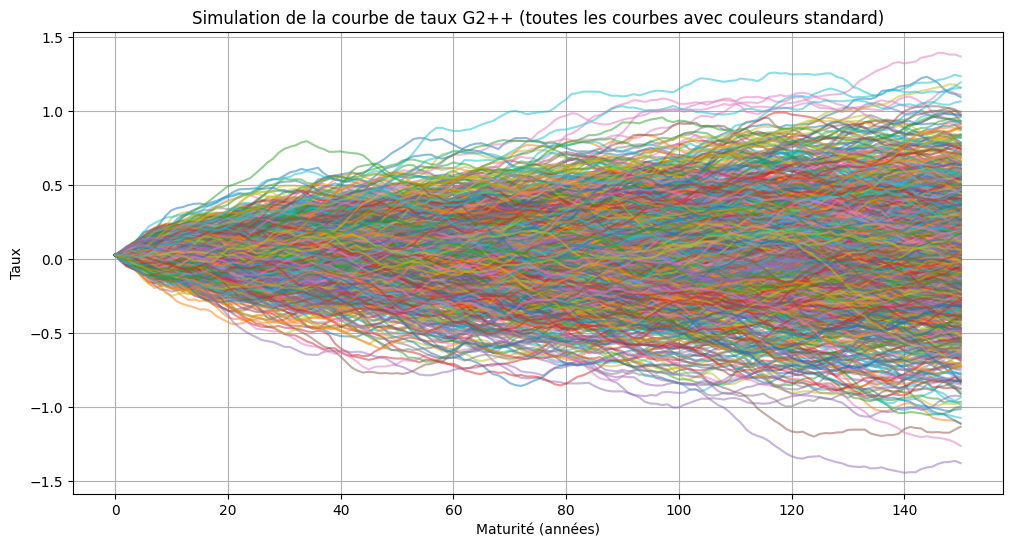

In [9]:
a, b, sigma, eta, rho = params
T = 150
N = 150  # nombre de pas de temps
dt = T / N  # discrétisation du temps
t_grid = np.linspace(0, T, N + 1)

list_r = []
list_x = []
list_y = []

for i in range(1000):
    # Génération des mouvements browniens corrélés W1 et W2
    dW1 = np.random.normal(0, np.sqrt(dt), N)
    dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt), N)

    W1 = np.concatenate(([0], np.cumsum(dW1)))
    W2 = np.concatenate(([0], np.cumsum(dW2)))

    # Simulation des processus x(t) et y(t)
    x = np.zeros(N + 1)
    y = np.zeros(N + 1)

    for t in range(1, N + 1):
        x[t] = x[t - 1] * np.exp(-a * dt) + sigma * np.sqrt((1 - np.exp(-2 * a * dt)) / (2 * a)) * W1[t]
        y[t] = y[t - 1] * np.exp(-b * dt) + eta * np.sqrt((1 - np.exp(-2 * b * dt)) / (2 * b)) * W2[t]

    r = {t: x[t_idx] + y[t_idx] + phi(t, a, b, sigma, eta, rho) for t_idx, t in enumerate(t_grid)}
    list_r.append(r)
    list_x.append(x)
    list_y.append(y)

plt.figure(figsize=(12, 6))
for r in list_r:
    plt.plot(list(r.keys()), list(r.values()), alpha=0.5)  # Pas de color spécifique

plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.title('Simulation de la courbe de taux G2++ (toutes les courbes avec couleurs standard)')
plt.grid()
plt.show()

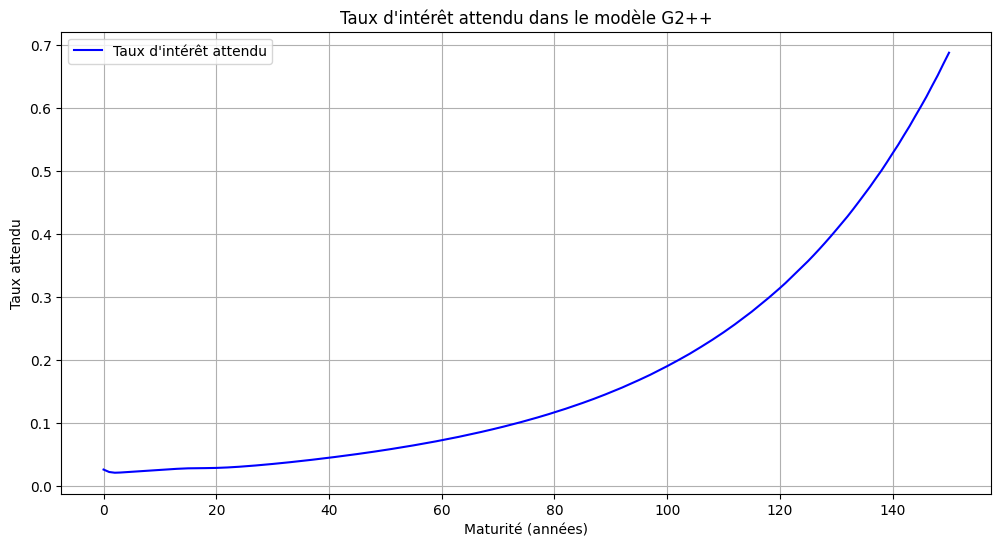

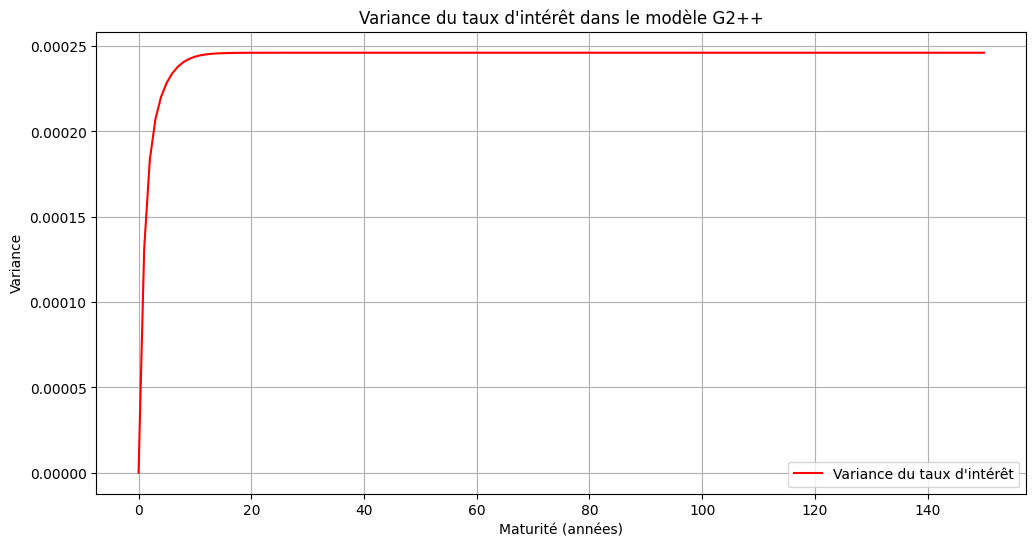

In [6]:
def expected_rate(t,a,b,sigma,eta,rho):
    """Calcul du taux d'intérêt attendu à maturité t dans le modèle G2++"""
    return compute_forward_rate(0, t) + ( sigma**2/(2*(a**2)) )*( (1 - np.exp(-a*t))**2 ) + eta**2/(2*(b**2))*( (1 - np.exp(-b*t))**2 ) + (rho*sigma*eta/(a*b))*(1 - np.exp(-a*t))*(1 - np.exp(-b*t))

def variance_rate(t,a,b,sigma,eta,rho):
    """Calcul de la variance du taux d'intérêt dans le modèle G2++"""
    return ( sigma**2/(2*(a)) )*(1 - np.exp(-2*a*t)) + eta**2/(2*(b))*(1 - np.exp(-2*b*t)) + (2*rho*sigma*eta/(a+b))*(1 - np.exp(-(a+b)*t))

# Calcul des taux d'intérêt attendus et des variances pour t dans t_grid
expected_rates = [expected_rate(t, a, b, sigma, eta, rho) for t in t_grid]
variances = [variance_rate(t, a, b, sigma, eta, rho) for t in t_grid]

# Tracé du taux d'intérêt attendu
plt.figure(figsize=(12, 6))
plt.plot(t_grid, expected_rates, label="Taux d'intérêt attendu", color='blue')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux attendu')
plt.title('Taux d\'intérêt attendu dans le modèle G2++')
plt.legend()
plt.grid()
plt.show()

# Tracé de la variance
plt.figure(figsize=(12, 6))
plt.plot(t_grid, variances, label="Variance du taux d'intérêt", color='red')
plt.xlabel('Maturité (années)')
plt.ylabel('Variance')
plt.title('Variance du taux d\'intérêt dans le modèle G2++')
plt.legend()
plt.grid()
plt.show()


- Test de market consistency

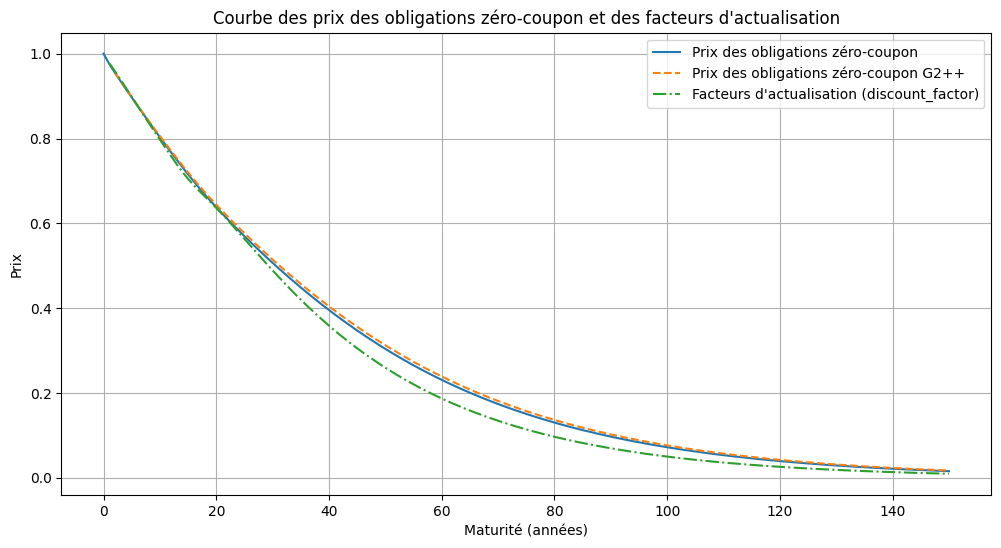

In [7]:
from scipy.interpolate import CubicSpline

interpolateur_zero_coupon = CubicSpline(eiopa_times, eiopa_rates, extrapolate=True)

def zero_coupon_price_marche(maturity):
    primitive_zero_coupon = interpolateur_zero_coupon.antiderivative()

    # Calcul de l'intégrale de 0 à T
    integrale_r_T = primitive_zero_coupon(maturity) - primitive_zero_coupon(0)

    # Calcul du prix de l'obligation zéro-coupon
    P_T = np.exp(-integrale_r_T)
    
    return P_T

# Calcul des prix zéro-coupon à partir des taux observés/interpolés
prices_zero_coupon_marche = {T : zero_coupon_price_marche(T) for T in eiopa_times}
prices_zero_coupon_marche[0] = 1


# Calcul des prix zéro-coupon à partir du modèle G2++
def A(t, T, a, b, sigma, eta, rho):

    Var = g2pp_variance(a, b, sigma, eta, rho, T)

    P_0_T = prices_zero_coupon_marche[T]
    P_0_t = prices_zero_coupon_marche[t]

    A_tT = (P_0_T/P_0_t)* np.exp(0.5 * (Var))

    return A_tT

def B(t, T, z):
    return (1 - np.exp(-z * (T - t))) / z

def prix_zero_coupon(t, T, a, b, sigma, eta, rho, x, y):
    A_tT = A(t, T, a, b, sigma, eta, rho)
    B_tT_a = B(t, T, a)
    B_tT_b = B(t, T, b)

    x_t = x[t]
    y_t = y[t]

    return A_tT * np.exp( - B_tT_a * x_t - B_tT_b  * y_t)

# Calcul des prix des obligations zéro-coupon P(0, T) avec le modèle G2++
zero_coupon_prices = {T : prix_zero_coupon(0, T, a, b, sigma, eta, rho, x_mean, y_mean) for T in eiopa_times[1:]}

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(sorted(prices_zero_coupon_marche.keys()), [prices_zero_coupon_marche[k] for k in sorted(prices_zero_coupon_marche.keys())], label='Prix des obligations zéro-coupon')
plt.plot(zero_coupon_prices.keys(), zero_coupon_prices.values(), label='Prix des obligations zéro-coupon G2++', linestyle='--')
plt.plot(eiopa_times, [discount_factor(t) for t in eiopa_times], label='Facteurs d\'actualisation (discount_factor)', linestyle='-.')
plt.xlabel('Maturité (années)')
plt.ylabel('Prix')
plt.legend()
plt.title('Courbe des prix des obligations zéro-coupon et des facteurs d\'actualisation')
plt.grid()
plt.show()



- Calcul des taux forward définis par :
$$
f(t,T) = -\frac{\partial \ln(P(t,T))}{\partial T}
$$  

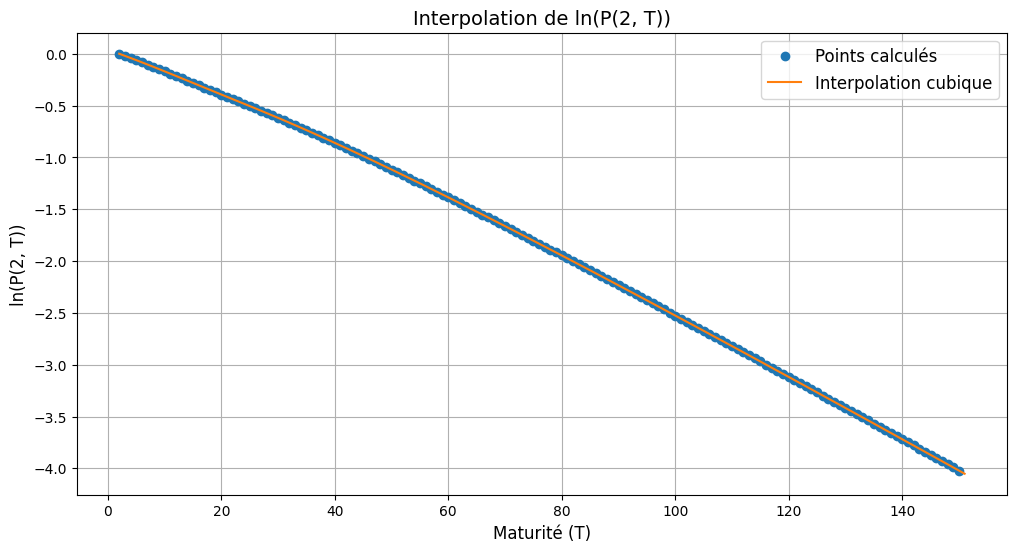

In [8]:
from scipy.interpolate import interp1d
import numpy as np

import matplotlib.pyplot as plt

# Calcul des ln(P(2, T)) pour T dans [2, 51]
T_values = np.arange(2, 151)
ln_P_values = []

for T in T_values:
    P_2_T = prix_zero_coupon(2, T, a, b, sigma, eta, rho, x_mean, y_mean)
    ln_P_values.append(np.log(P_2_T))

# Interpolation de la courbe ln(P(2, T)) par spline cubique
interpolateur_ln_P = CubicSpline(T_values, ln_P_values, extrapolate=True)

# Tracé de la courbe interpolée
T_dense = np.linspace(2, 151, 149)
ln_P_dense = interpolateur_ln_P(T_dense)

plt.figure(figsize=(12, 6))
plt.plot(T_values, ln_P_values, 'o', label='Points calculés')
plt.plot(T_dense, ln_P_dense, '-', label='Interpolation cubique')
plt.xlabel('Maturité (T)', fontsize=12)
plt.ylabel('ln(P(2, T))', fontsize=12)
plt.title('Interpolation de ln(P(2, T))', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

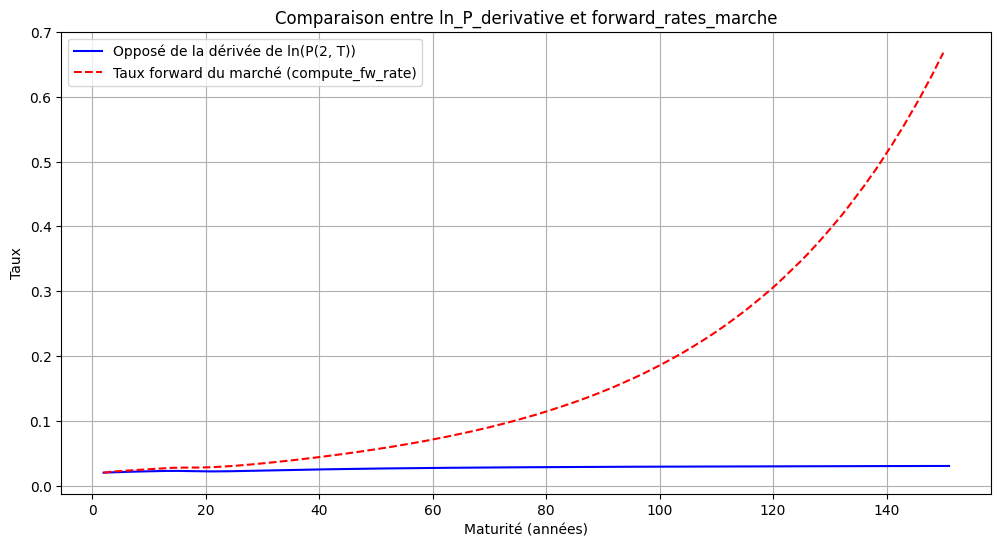

Erreur moyenne entre ln_P_derivative et forward_rates_marche (compute_fw_rate): 0.147781


C:\Users\massi\AppData\Local\Temp\ipykernel_38164\881185245.py:6: RuntimeWarning: invalid value encountered in scalar divide
  fwr_m = (-np.log(prices_zero_coupon_marche[T])+np.log(prices_zero_coupon_marche[t]))/(T-t)


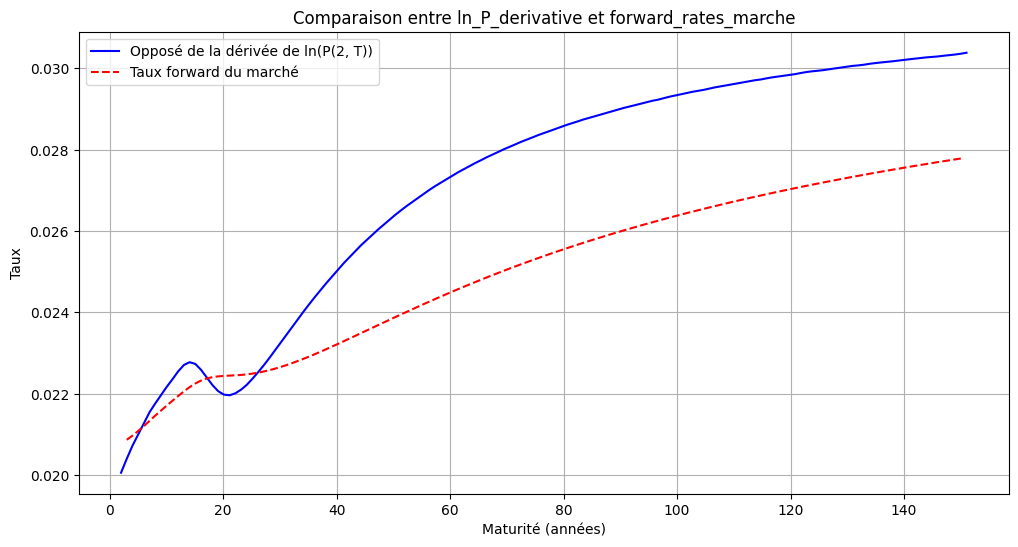

Erreur moyenne entre ln_P_derivative et forward_rates_marche: 0.002249
Erreur moyenne entre ln_P_derivative et forward_rates_marchee (from discount fact): 0.000800


C:\Users\massi\AppData\Local\Temp\ipykernel_38164\881185245.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return (np.log(P_t) - np.log(P_T)) / (T - t)


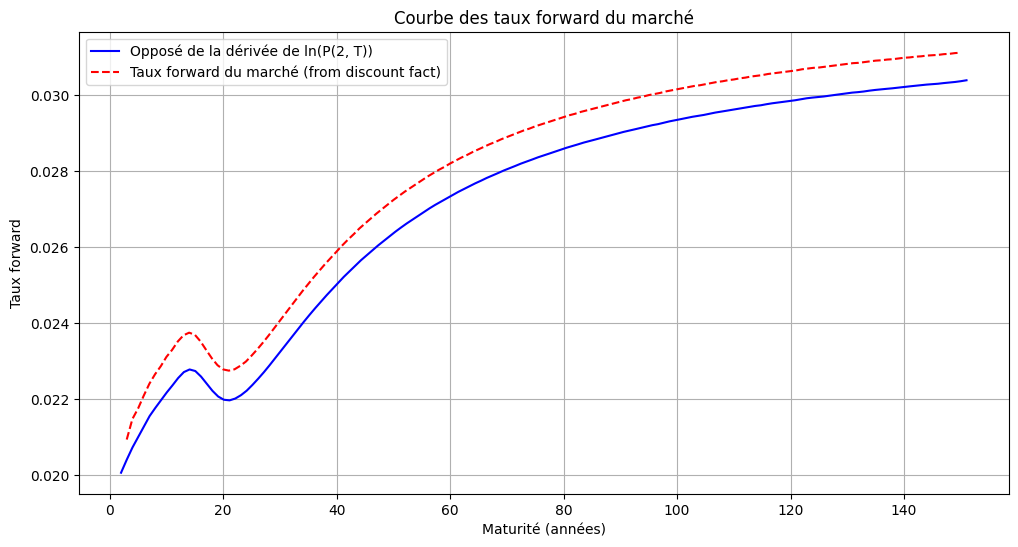

In [10]:
# Calcul de l'opposé de la dérivée de ln(P(2, T)) à l'aide de l'interpolateur
ln_P_derivative = -interpolateur_ln_P.derivative()(T_dense)


def forward_rate_marche(t,T):
    fwr_m = (-np.log(prices_zero_coupon_marche[T])+np.log(prices_zero_coupon_marche[t]))/(T-t)
    return fwr_m




def forward_rate_from_discount(t, T):
    P_t = discount_factor(t)
    P_T = discount_factor(T)
    return (np.log(P_t) - np.log(P_T)) / (T - t)



forward_rates_marche_computed = {T : compute_forward_rate(2, T) for T in range(2,151)}


# Figure: Comparaison entre ln_P_derivative et forward_rates_marche
plt.figure(figsize=(12, 6))
plt.plot(T_dense, ln_P_derivative, label="Opposé de la dérivée de ln(P(2, T))", color='blue')
plt.plot(forward_rates_marche_computed.keys(), forward_rates_marche_computed.values(), label="Taux forward du marché (compute_fw_rate)", color='red', linestyle='--')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.title('Comparaison entre ln_P_derivative et forward_rates_marche')
plt.legend()
plt.grid()
plt.show()

# Calcul de l'erreur moyenne
error_1 = np.mean(np.abs(ln_P_derivative - list(forward_rates_marche_computed.values())))
print(f"Erreur moyenne entre ln_P_derivative et forward_rates_marche (compute_fw_rate): {error_1:.6f}")

forward_rates_marche = {T: forward_rate_marche(2, T) for T in range(2,151)}

# Figure: Comparaison entre ln_P_derivative et forward_rates_marche
plt.figure(figsize=(12, 6))
plt.plot(T_dense, ln_P_derivative, label="Opposé de la dérivée de ln(P(2, T))", color='blue')
plt.plot(forward_rates_marche.keys(), forward_rates_marche.values(), label="Taux forward du marché", color='red', linestyle='--')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.title('Comparaison entre ln_P_derivative et forward_rates_marche')
plt.legend()
plt.grid()
plt.show()

# Calcul de l'erreur moyenne en ignorant les NaN
ln_P_derivative_clean = np.array(ln_P_derivative)
forward_rates_marche_clean = np.array(list(forward_rates_marche.values()))
mask_2 = ~np.isnan(ln_P_derivative_clean) & ~np.isnan(forward_rates_marche_clean)
error_2 = np.mean(np.abs(ln_P_derivative_clean[mask_2] - forward_rates_marche_clean[mask_2]))
print(f"Erreur moyenne entre ln_P_derivative et forward_rates_marche: {error_2:.6f}")

forward_rates_marchee = {T: forward_rate_from_discount(2, T) for T in range(2, 151)}

# Calcul de l'erreur moyenne en ignorant les NaN
forward_rates_marchee_clean = np.array(list(forward_rates_marchee.values()))
mask_3 = ~np.isnan(ln_P_derivative_clean) & ~np.isnan(forward_rates_marchee_clean)
error_3 = np.mean(np.abs(ln_P_derivative_clean[mask_3] - forward_rates_marchee_clean[mask_3]))
print(f"Erreur moyenne entre ln_P_derivative et forward_rates_marchee (from discount fact): {error_3:.6f}")

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(T_dense, ln_P_derivative, label="Opposé de la dérivée de ln(P(2, T))", color='blue')
plt.plot(forward_rates_marchee.keys(), forward_rates_marchee.values(), label='Taux forward du marché (from discount fact)', color='red', linestyle='--')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux forward')
plt.legend()
plt.title('Courbe des taux forward du marché')
plt.grid()
plt.show()




In [40]:
print(len(T_dense), len(forward_rates_marchee.values()))

149 149
